NaN count: 11550
Min: nan, Max: nan
Dataset loaded successfully. Total points: 107167
  OK: LogNormalFactory
  OK: WeibullMinFactory
  OK: GammaFactory
  OK: ExponentialFactory
  OK: WeibullMaxFactory
  OK: RayleighFactory

WINNING DISTRIBUTION MODEL
WeibullMin(beta = 0.528664, alpha = 1.2934, gamma = 0.0119857)
BIC Score: 0.4786


c:\Users\arthu\tudelft-conda\envs\mude-base\Lib\site-packages\openturns\viewer.py:907: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self._fig.show(**kwargs)


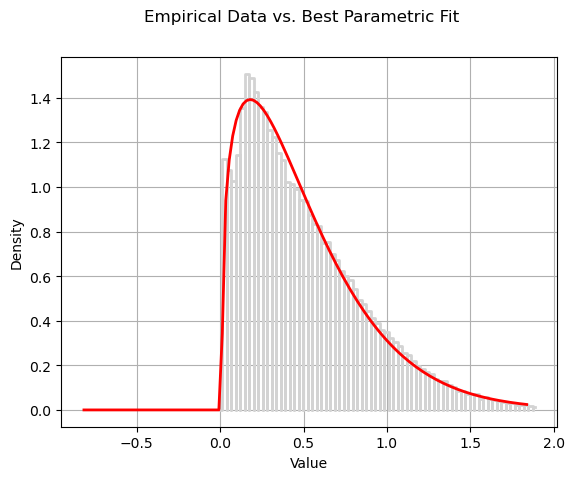

In [ ]:
import openturns as ot
import numpy as np
import pandas as pd

wave_data_comb = pd.read_csv('hs_1940_2025_new.csv')
sample_np = wave_data_comb['Hs'].values

# Sanity checks on raw data
print(f"NaN count: {np.isnan(sample_np).sum()}")
print(f"Min: {sample_np.min():.4f}, Max: {sample_np.max():.4f}")

# Drop NaNs and non-positive values (required for LogNormal, Weibull, Gamma, Exponential)
sample_np = sample_np[~np.isnan(sample_np)]
sample_np = sample_np[sample_np > 0.01]

sample = ot.Sample(sample_np.reshape(-1, 1))
print(f"Dataset loaded successfully. Total points: {sample.getSize()}")


candidates = [
    ot.LogNormalFactory(),
    ot.WeibullMinFactory(),
    ot.GammaFactory(),
    ot.ExponentialFactory(),
    ot.WeibullMaxFactory(),
    ot.RayleighFactory()
]

# Filter to only factories that can actually fit this sample
working_factories = []
for factory in candidates:
    try:
        dist = factory.build(sample)
        working_factories.append(factory)
        print(f"  OK: {factory.getClassName()}")
    except Exception as e:
        print(f"  SKIP {factory.getClassName()}: {e}")

if not working_factories:
    raise RuntimeError("No factories could fit the data. Check your sample.")

factory_collection = ot.DistributionFactoryCollection(working_factories)

# BestModelBIC returns a TUPLE: (best_distribution, bic_score)
best_distribution, best_bic = ot.FittingTest.BestModelBIC(sample, factory_collection)

print("\n" + "="*40)
print("WINNING DISTRIBUTION MODEL")
print("="*40)
print(best_distribution)
print(f"BIC Score: {best_bic:.4f}")


graph = ot.Graph("Empirical Data vs. Best Parametric Fit", "Value", "Density", True)

histogram_plot = ot.HistogramFactory().build(sample).drawPDF()
histogram_plot.setColors(["lightgray"])
graph.add(histogram_plot)

pdf_curve = best_distribution.drawPDF()
pdf_curve.setColors(["red"])
pdf_curve.setLegends([best_distribution.getClassName()])
graph.add(pdf_curve)

from openturns.viewer import View
view = View(graph)
view.show();

NaN count: 11550
Min: nan, Max: nan
Dataset loaded successfully. Total points: 114098
  OK: LogNormalFactory
  OK: WeibullMinFactory
  OK: GammaFactory
  OK: ExponentialFactory
  OK: WeibullMaxFactory
  OK: RayleighFactory

WINNING DISTRIBUTION MODEL
LogNormal(muLog = 0.304867, sigmaLog = 0.475882, gamma = 1.4626)
BIC Score: 1.9627


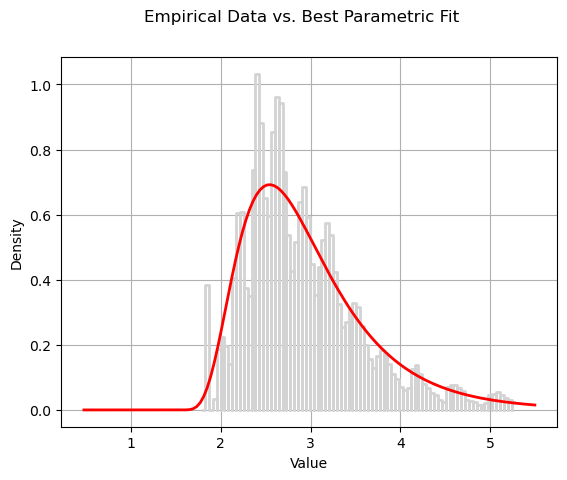

In [ ]:
sample_np = wave_data_comb['Tp'].values

# Sanity checks on raw data
print(f"NaN count: {np.isnan(sample_np).sum()}")
print(f"Min: {sample_np.min():.4f}, Max: {sample_np.max():.4f}")

# Drop NaNs and non-positive values (required for LogNormal, Weibull, Gamma, Exponential)
sample_np = sample_np[~np.isnan(sample_np)]
sample_np = sample_np[sample_np > 0.01]

sample = ot.Sample(sample_np.reshape(-1, 1))
print(f"Dataset loaded successfully. Total points: {sample.getSize()}")

candidates = [
    ot.LogNormalFactory(),
    ot.WeibullMinFactory(),
    ot.GammaFactory(),
    ot.ExponentialFactory(),
    ot.WeibullMaxFactory(),
    ot.RayleighFactory()
]

working_factories = []
for factory in candidates:
    try:
        dist = factory.build(sample)
        working_factories.append(factory)
        print(f"  OK: {factory.getClassName()}")
    except Exception as e:
        print(f"  SKIP {factory.getClassName()}: {e}")

if not working_factories:
    raise RuntimeError("No factories could fit the data. Check your sample.")

factory_collection = ot.DistributionFactoryCollection(working_factories)


best_distribution, best_bic = ot.FittingTest.BestModelBIC(sample, factory_collection)

print("\n" + "="*40)
print("WINNING DISTRIBUTION MODEL")
print("="*40)
print(best_distribution)
print(f"BIC Score: {best_bic:.4f}")

graph = ot.Graph("Empirical Data vs. Best Parametric Fit", "Value", "Density", True)

histogram_plot = ot.HistogramFactory().build(sample).drawPDF()
histogram_plot.setColors(["lightgray"])
graph.add(histogram_plot)

pdf_curve = best_distribution.drawPDF()
pdf_curve.setColors(["red"])
pdf_curve.setLegends([best_distribution.getClassName()])
graph.add(pdf_curve)

from openturns.viewer import View
view = View(graph)
view.show();

In [7]:
# empirical and fitted upper quantiles
probs = [0.9, 0.95, 0.98, 0.99, 0.995, 0.999]
emp_q = np.quantile(sample_np, probs)
fit_q = [best_distribution.computeQuantile(p)[0] for p in probs]

pd.DataFrame({
    "p": probs,
    "empirical": emp_q,
    "fitted": fit_q,
    "relative_error": (np.array(fit_q) - emp_q) / emp_q
})

,p,empirical,fitted,relative_error
0,0.900,3.918800,3.958708,0.010184
1,0.950,4.580946,4.429808,-0.032993
2,0.980,5.468117,5.067188,-0.073321
3,0.990,6.077003,5.566478,-0.084009
4,0.995,6.301516,6.083808,-0.034549
5,0.999,7.233253,7.365544,0.018289
